##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec07"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/cifar10"
    !mkdir -p {DATASET_PATH}
    !cp -n {WORK_DIR}{DATASET_PATH}.zip {DATASET_PATH}.zip
    !unzip -qn {DATASET_PATH}.zip -d {DATASET_PATH}
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print()

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/cifar10"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False


[데이터셋 폴더 목록]
../datasets/cifar10
test  train  val  

##### 임포트

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

##### Device 설정

In [3]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


##### RGB 평균/표준편차 계산 함수

In [4]:
# # transforms.Normalize(RGB_MEAN, RGB_STD) 사용을 위한
# # 훈련 데이터셋의 채널별 평균/표준편차 계산 함수 정의
# def calculate_mean_std(path:str):
#     # Dataset 생성
#     train_dataset = datasets.ImageFolder(
#         path,
#         # PIL (H, W, C) → [0 ~ 1.0] 범위의 (C, H, W) 텐서로 변환
#         transform=transforms.ToTensor()
#     )

#     # 배치 단위로 데이터를 불러오기 위해 DataLoader 생성
#     train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False, num_workers=4)

#     # 채널별 누적합을 저장할 Tensor 초기화
#     channel_sum    = torch.zeros(3)

#     # 채널별 제곱 누적합을 저장할 Tensor 초기화
#     channel_sum_sq = torch.zeros(3)

#     # 전체 픽셀 수를 저장할 변수 초기화
#     pixel_count    = 0

#     # DataLoader로 배치 단위로 데이터를 불러옴
#     for images, _ in train_loader:
#         # images shape: (batch, 3, 32, 32)
#         channel_sum    += images.sum(dim=[0, 2, 3])      # 배치·높이·너비 방향 합산
#         channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
#         pixel_count    += images.shape[0] * images.shape[2] * images.shape[3]

#     # 채널별 평균과 표준편차 계산
#     mean = channel_sum / pixel_count                         # tensor shape: (3,)
#     std  = (channel_sum_sq / pixel_count - mean ** 2).sqrt() # tensor shape: (3,)

#     return mean.tolist(), std.tolist()

# # 훈련 데이터셋의 채널별 평균과 표준편차 계산
# mean, std = calculate_mean_std(DATASET_PATH + "/train")
# print("CIFAR-10 훈련 데이터셋의 채널별 평균:", mean)
# print("CIFAR-10 훈련 데이터셋의 채널별 표준편차:", std)


##### Transform 정의(표준화 하기)

In [5]:
# 앞에서 계산한 mean, std를 튜플로 변환해 사용
# RGB_MEAN = tuple(mean)  # R, G, B 채널 평균
# RGB_STD  = tuple(std)   # R, G, B 채널 표준편차

RGB_MEAN = (0.491350919008255, 0.48206818103790283, 0.4465498626232147)   # R, G, B 채널 평균
RGB_STD  = (0.24713236093521118, 0.2436210662126541, 0.2617213726043701)  # R, G, B 채널 표준편차

# 전처리 파이프라인 정의
transform = transforms.Compose([
    # PIL Image (H, W, C) uint8  0 ~ 255에서 Tensor (C, H, W) float32 0.0 ~ 1.0 로 변환
    transforms.ToTensor(),
    # 채널별로 표준화하기
    # - ToTensor()만으로도 학습은 가능하지만, 표준화와 함께 쓰는 것이
    # - 정확도와 수렴 속도 면에서 유리하여 실무에서 거의 항상 같이 사용
    transforms.Normalize(RGB_MEAN, RGB_STD)
])

##### 훈련/검증/테스트별로 Dataset 생성  

In [6]:
# ImageFolder를 이용해서 Dataset 생성
train_dataset = datasets.ImageFolder(DATASET_PATH + "/train", transform=transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH + "/val",   transform=transform)
test_dataset  = datasets.ImageFolder(DATASET_PATH + "/test",  transform=transform)

print(f"학습 데이터셋 크기  : {len(train_dataset):5d} 개")
print(f"검증 데이터셋 크기  : {len(val_dataset):5d} 개")
print(f"테스트 데이터셋 크기: {len(test_dataset):5d} 개")
print(f"클래스 목록: {train_dataset.classes}")
print(f"클래스 인덱스: {train_dataset.class_to_idx}")

학습 데이터셋 크기  : 45000 개
검증 데이터셋 크기  :  5000 개
테스트 데이터셋 크기: 10000 개
클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
클래스 인덱스: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


##### 훈련/검증/테스트별로 DataLoader 생성

In [7]:
# 배치 크기 설정
# - 작을 수록(16~32): 일반화 성능 UP, 과적합 방지에 유리, 학습 속도 Down, GPU를 충분히 활용하지 못함
# - 클수록(128~512): 일반화 성능 Down, 과적합 발생 증가 가능, 학습 속도 UP, GPU를 충분히 활용 
# - 64: GPU 메모리 사용량과 학습 속도, 일반화 성능을 적절히 고려한 값으로, 대부분의 경우 적절한 선택
BATCH_SIZE  = 64

# DataLoader에서 데이터를 불러올 때 사용할 워커(worker) 수
# 무료 코랩은 보통 CPU 2코어 제공. 코어 수보다 많은 worker는 효과 없고 오히려 오버헤드 발생
NUM_WORKERS = 2

# 훈련용 DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True, # 매 에포크마다 순서를 섞어 과적합 방지
    num_workers=NUM_WORKERS,
)
# 검증용 DataLoader 생성
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)
# 테스트용 DataLoader 생성
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # 검증/테스트는 순서 고정
    num_workers=NUM_WORKERS,
)

print(f"train 배치 수: {len(train_loader)}")   # 45000 / 64 = 704
print(f"val   배치 수: {len(val_loader)}")     # 5000  / 64 = 79
print(f"test  배치 수: {len(test_loader)}")    # 10000 / 64 = 157


train 배치 수: 704
val   배치 수: 79
test  배치 수: 157


##### 배치 데이터 확인

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
/var/folders/vm/x2kw90

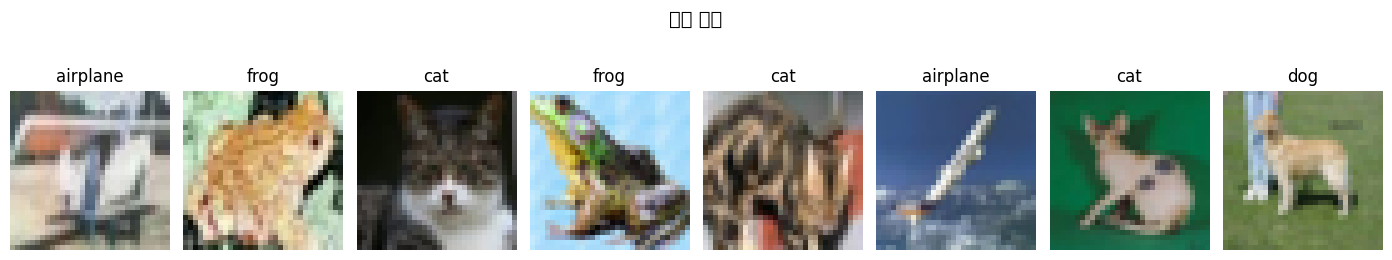

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family

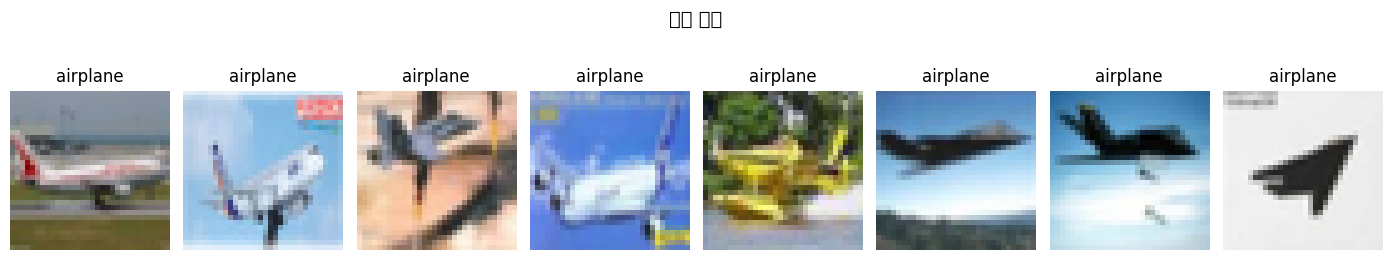

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=1)
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_17471/1504387134.py:33: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  pl

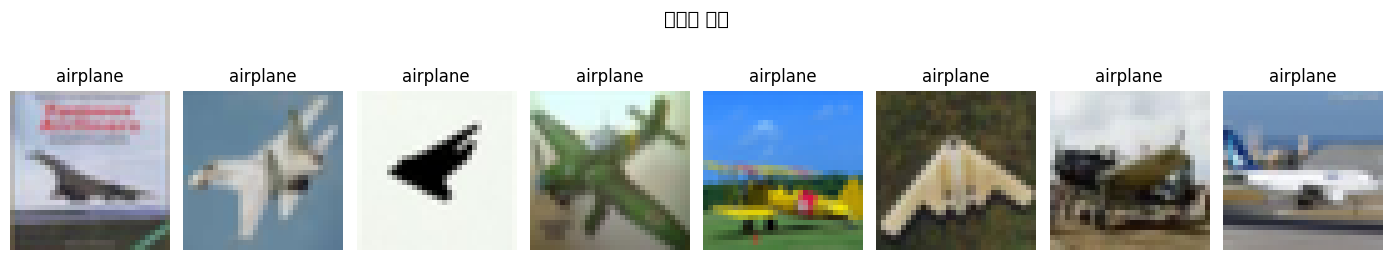

In [8]:
# DataLoader에서 배치 단위로 샘플 이미지를 시각화하는 함수
def show_batch_sample(title:str, dataset:Dataset, loader:DataLoader, rgb_mean:tuple, rgb_std:tuple):
    # DataLoader에서 첫 번째 배치 꺼내기
    # images: (batch_size, 3, 32, 32) 형태의 Tensor
    # labels: (batch_size,) 형태의 Tensor
    images, labels = next(iter(loader))

    # 배치에서 샘플 이미지 8장을 보여줄 서브 플롯 생성
    fig, axes = plt.subplots(1, 8, figsize=(14, 3))
    fig.suptitle(title, fontsize=14)

    # view(3, 1, 1): 브로드캐스팅을 위해 (3,) → (3, 1, 1) 형태로 변환
    mean = torch.tensor(rgb_mean).view(3, 1, 1)
    std  = torch.tensor(rgb_std).view(3, 1, 1)

    # images[:8]: 배치에서 처음 8장 이미지 선택 (shape: (8, 3, 32, 32))
    for ax, img, lbl in zip(axes, images[:8], labels[:8]):
        # DataLoader로 불러온 이미지는 이미 표준화된 상태이므로, 시각화를 위해 표준화 역변환을 수행
        # 표준화 역변환: (표준화된 값 × std) + mean
        img_display = img * std + mean
        # 픽셀값을 0~1 범위로 클리핑 (표준화 역변환 후 범위를 벗어나는 값 보정)
        # -0.05  →  0.0   (하한 보정)
        #  0.53  →  0.53  (그대로)
        #  1.02  →  1.0   (상한 보정)
        img_display = img_display.clamp(0, 1)   # 픽셀값을 0~1 범위로 클램프
        # (C, H, W) → (H, W, C)
        img_display = img_display.permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)

        ax.imshow(img_display)
        ax.set_title(dataset.classes[lbl], fontsize=12)
        ax.axis("off")

    plt.tight_layout(pad=1)
    plt.show()

show_batch_sample("훈련 샘플", train_dataset, train_loader, RGB_MEAN, RGB_STD)
show_batch_sample("검증 샘플", val_dataset, val_loader, RGB_MEAN, RGB_STD)
show_batch_sample("테스트 샘플", test_dataset, test_loader, RGB_MEAN, RGB_STD)
